## Training zoom
code was adapted from 
https://github.com/kinivi/hand-gesture-recognition-mediapipe/blob/main/keypoint_classification_EN.ipynb
and 
https://www.tensorflow.org/api_docs/python/tf/keras/Model
and 
https://www.youtube.com/watch?v=a99p_fAr6e4&t=899s 

In [1]:
import os
import csv
import json
import numpy as np

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

In [2]:
ANNOTATIONS_DIR = 'annotations'
OUTPUT_CSV = 'data/zoom.csv'
os.makedirs("data", exist_ok=True)
os.makedirs("model", exist_ok=True)

def extract_all_samples():
    all_samples = []
    
    gestures = {
        'thumb_index': 1,     
        'three_gun': 0,    
        'point': 0,
        'palm': 0,
        'peace': 0
    }
    
    for gesture_name, label in gestures.items():
        print(f"Processing {gesture_name} (label={label})")
        
        for split in ['test', 'train', 'val']:
            json_path = f'{ANNOTATIONS_DIR}/{split}/{gesture_name}.json'
            
            try:
                with open(json_path, 'r') as f:
                    data = json.load(f)
            except FileNotFoundError:
                print(f"(file not found)")
                continue
            
            count = 0
            
            for image_id, annotation in data.items():
                if 'hand_landmarks' not in annotation:
                    continue
                if not annotation['hand_landmarks']:
                    continue
                
                for hand in annotation['hand_landmarks']:
                    if hand is None or len(hand) != 21:
                        continue
                    
                    # flatten to 2D (x, y) to store all coordinates
                    landmarks_flat = []
                    for point in hand:
                        if len(point) >= 2:
                            landmarks_flat.extend([point[0], point[1]])
                    
                    if len(landmarks_flat) == 42:
                        all_samples.append([label] + landmarks_flat)
                        count += 1
                
                # limit negatives to balance dataset
                if label == 0 and count >= 5000:
                    break
            
            print(f"{split}: {count} samples")
    
    print(f"Total samples: {len(all_samples)}")
    
    labels = [s[0] for s in all_samples]
    print(f"Label 0 (not zoom): {labels.count(0)}")
    print(f"Label 1 (zoom): {labels.count(1)}")
    
    with open(OUTPUT_CSV, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(all_samples)
    
    print(f"Saved to {OUTPUT_CSV}")

extract_all_samples()

Processing thumb_index (label=1)
test: 6076 samples
train: 46956 samples
val: 3737 samples
Processing three_gun (label=0)
test: 5000 samples
train: 5000 samples
val: 3845 samples
Processing point (label=0)
test: 5000 samples
train: 5000 samples
val: 3548 samples
Processing palm (label=0)
test: 5000 samples
train: 5001 samples
val: 3609 samples
Processing peace (label=0)
test: 5000 samples
train: 5000 samples
val: 3577 samples
Total samples: 111349
Label 0 (not zoom): 54580
Label 1 (zoom): 56769
Saved to data/zoom.csv


In [3]:
RANDOM_SEED = 42

dataset = 'data/zoom.csv'
model_save_path = 'model/zoom_gesture_model.keras'
tflite_save_path = 'model/zoom_gesture_model.tflite'

NUM_CLASSES = 2

data = np.loadtxt(dataset, delimiter=',', dtype='float32')
X_dataset = data[:, 1:]             
y_dataset = data[:, 0].astype('int32')  

In [4]:
print(f"dataset shape: {X_dataset.shape}")
print(f"label distribution:")

unique, counts = np.unique(y_dataset, return_counts=True)

for label, count in zip(unique, counts):
    label_name = "Not Zoom" if label == 0 else "Zoom"
    print(f"{label} ({label_name}): {count} samples ({count/len(y_dataset)*100:.1f}%)")

# check for class imbalance
imbalance_ratio = max(counts) / min(counts)
print(f"\nImbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 2.0:
    print("WARNING: Significant class imbalance detected!")
    print("Will use class weights to compensate")

print("\nData validation:")
print(f"Feature range: [{X_dataset.min():.3f}, {X_dataset.max():.3f}]") # expected [0,1] range
print(f"Feature mean: {X_dataset.mean():.3f}")
print(f"Contains NaN: {np.isnan(X_dataset).any()}")
print(f"Contains Inf: {np.isinf(X_dataset).any()}")

# check if features are normalised (should be 0-1 for landmarks)
if X_dataset.min() < -0.1 or X_dataset.max() > 1.1:
    print("erm bro features outside expected [0,1] range")

dataset shape: (111349, 42)
label distribution:
0 (Not Zoom): 54580 samples (49.0%)
1 (Zoom): 56769 samples (51.0%)

Imbalance ratio: 1.04

Data validation:
Feature range: [-0.056, 1.101]
Feature mean: 0.512
Contains NaN: False
Contains Inf: False
erm bro features outside expected [0,1] range


In [5]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_dataset, y_dataset, 
    test_size = 0.25,
    train_size = 0.75, 
    random_state = RANDOM_SEED,
    stratify = y_dataset   
)

print(f"train samples: {len(X_train)}")
print(f"test samples: {len(X_test)}")

print("\ntrain label distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"{label}: {count} ({count/len(y_train)*100:.1f}%)")

train samples: 83511
test samples: 27838

train label distribution:
0: 40935 (49.0%)
1: 42576 (51.0%)


In [6]:
class_weights_array = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

print(f"Class weights: {class_weights}")

Class weights: {0: 1.020043972150971, 1: 0.980728579481398}


In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2,)),
    
    # normalisation
    tf.keras.layers.BatchNormalization(),
    
    # Main network
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

# add extra layer if too bad

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 42)             │           168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,106 (8.23 KB)

 Trainable params: 2,022 (7.90 KB)

 Non-trainable params: 84 (336.00 B)

In [8]:
# model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, 
    verbose=1, 
    save_best_only=True,
    save_weights_only=False
)

# callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(
    patience=30, 
    verbose=1,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    #monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights,  # handle imbalance in weights seen above gng
    callbacks=[cp_callback, es_callback, reduce_lr],
    verbose=1
)


Epoch 1/200
2541/2610 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - accuracy: 0.7848 - loss: 0.4184
Epoch 1: val_loss improved from None to 0.16733, saving model to model/zoom_gesture_model.keras

Epoch 1: finished saving model to model/zoom_gesture_model.keras
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 2s 677us/step - accuracy: 0.8593 - loss: 0.2873 - val_accuracy: 0.9076 - val_loss: 0.1673 - learning_rate: 0.0010
Epoch 2/200
2567/2610 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step - accuracy: 0.9004 - loss: 0.2004
Epoch 2: val_loss improved from 0.16733 to 0.16375, saving model to model/zoom_gesture_model.keras

Epoch 2: finished saving model to model/zoom_gesture_model.keras
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 2s 675us/step - accuracy: 0.8990 - loss: 0.1981 - val_accuracy: 0.9146 - val_loss: 0.1638 - learning_rate: 0.0010
Epoch 3/200
2592/2610 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.9005 - loss: 0.1910
Epoch 3: val_loss improved from 0.16375 to 0.15911, saving model to model/zoom_gesture_model.keras

Epoch 3: f

In [9]:
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step - accuracy: 0.9238 - loss: 0.1270


In [10]:
model.save(model_save_path, include_optimizer=False)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

with open(tflite_save_path, 'wb') as f:
    f.write(tflite_quantized_model)

print(f"Keras model saved: {model_save_path}")
print(f"TFLite saved: {tflite_save_path}")


INFO:tensorflow:Assets written to: /var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmphgu99vv6/assets


INFO:tensorflow:Assets written to: /var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmphgu99vv6/assets


Saved artifact at '/var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmphgu99vv6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  13145403280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13145404624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13145404240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13145404432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13145406160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13145405008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13145405968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13145403088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13145406544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13145406352: TensorSpec(shape=(), dtype=tf.resource, name=None)
Keras model saved: mo

W0000 00:00:1777652485.844979 17754091 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1777652485.844989 17754091 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1777652485.849254 17754091 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


870/870 ━━━━━━━━━━━━━━━━━━━━ 0s 235us/step


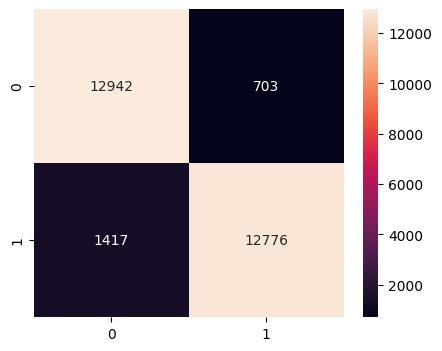

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     13645
           1       0.95      0.90      0.92     14193

    accuracy                           0.92     27838
   macro avg       0.92      0.92      0.92     27838
weighted avg       0.93      0.92      0.92     27838



In [11]:
import pandas as pd
import seaborn as sns

# confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)